In [12]:
import uproot
import pandas as pd
from sklearn.model_selection import train_test_split

#combine files
data = uproot.concatenate("*.root:AnalysisMiniTree", library = "pd")

#pull weight
weight_cols = [c for c in data.columns if "weight" in c.lower()]
weight_data = data[weight_cols]
data = data.drop(columns=weight_cols)

#split data
train_df, val_df = train_test_split(data, test_size=0.2, random_state=42)

# check it
print(train_df.shape)
print(val_df.shape)
print(data.shape)
data.head()


(1587097, 121)
(396775, 121)
(1983872, 121)


,dsid,hhml_subChannelFlavor,n_jet,n_b_jet,met_met,met_phi,met_sumet,pass_SLT,pass_DLT,pass_STT,...,tau2_truthType,tau2_truth_IsHadronicTau,isTrueTauEvents,isSingleFakeTau,isDiTauFakes,fjvt_effSF,ftag_effSF_GN2v01_Continuous,globalTriggerEffSF,jvt_effSF,eventNumber
0,701040,1,3,0,28304.958984,-1.782333,286317.218750,1,0,0,...,1.0,1.0,1,0,0,1.0,0.974690,0.970220,0.974690,1535543
1,701040,2,1,0,72332.281250,-3.075798,295467.312500,1,0,0,...,1.0,1.0,1,0,0,1.0,0.995817,1.004455,0.995817,1432474
2,701040,1,1,0,37495.507812,1.310638,417087.312500,0,0,1,...,1.0,1.0,1,0,0,1.0,0.995817,1.000000,0.995817,1432470
3,701040,1,2,0,71157.359375,-2.591286,235826.578125,1,0,0,...,1.0,1.0,1,0,0,1.0,1.064509,0.967280,1.064509,1428941
4,701040,2,1,0,51801.027344,1.928192,217189.781250,1,0,0,...,1.0,1.0,1,0,0,1.0,0.992887,0.792078,0.992887,1935280


In [ ]:
#removes empty branches so no NAN error
nan_cols = train_df.columns[train_df.isna().all()]
train_df = train_df.drop(columns=nan_cols)
val_df = val_df.drop(columns=nan_cols)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fit then rescale
train_df[train_df.columns] = scaler.fit_transform(train_df)
val_df[val_df.columns] = scaler.transform(val_df)

train_df.head(10)

,dsid,hhml_subChannelFlavor,n_jet,n_b_jet,met_met,met_phi,met_sumet,pass_SLT,pass_DLT,pass_STT,...,tau2_truthType,tau2_truth_IsHadronicTau,isTrueTauEvents,isSingleFakeTau,isDiTauFakes,fjvt_effSF,ftag_effSF_GN2v01_Continuous,globalTriggerEffSF,jvt_effSF,eventNumber
929881,0.606707,1.0,0.294118,0.142857,0.008469,0.656634,0.061994,1.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.550524,0.219404,0.653857,0.219404,0.015925
1590068,0.998819,1.0,0.058824,0.000000,0.000755,0.386589,0.018892,1.0,0.0,0.0,...,0.2,1.0,0.0,1.0,0.0,0.550524,0.248885,0.794653,0.248885,0.785724
704102,0.504290,1.0,0.235294,0.285714,0.012400,0.623054,0.051921,1.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.550524,0.254364,0.678056,0.254364,0.001235
952298,0.606709,0.0,0.176471,0.142857,0.016987,0.647651,0.043004,1.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.550524,0.255489,0.784064,0.255489,0.027753
627848,0.997679,0.0,0.176471,0.000000,0.002972,0.796196,0.057491,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.550524,0.243867,0.718146,0.243867,0.315643
103030,0.999454,0.0,0.176471,0.142857,0.024022,0.696955,0.043846,1.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.550524,0.217426,0.760208,0.217426,0.021347
1976629,0.267984,0.0,0.058824,0.000000,0.009697,0.293775,0.036138,1.0,0.0,0.0,...,0.2,1.0,0.0,1.0,0.0,0.550524,0.248885,0.784721,0.248885,0.437034
228193,0.999454,0.0,0.058824,0.000000,0.010215,0.497691,0.012438,0.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.550524,0.248885,0.784105,0.248885,0.065884
1659726,0.106558,1.0,0.235294,0.285714,0.010622,0.191024,0.048473,1.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.550524,0.226674,0.795178,0.226674,0.002844
425597,0.999441,0.0,0.294118,0.000000,0.010447,0.229568,0.070384,1.0,0.0,0.0,...,0.2,1.0,1.0,0.0,0.0,0.556155,0.260297,0.786612,0.260297,0.152925


In [14]:
# split weights to match train_df/val_df
train_weights, val_weights = train_test_split(weight_df, test_size=0.2, random_state=42)

# check it
print(train_weights.shape)
print(val_weights.shape)
weight_data.head()

(1587097, 9)
(396775, 9)


,tau1_weight_ff,tau2_weight_ff,weights,weight_ff,weight_final,weights_detector,weights_mc,weights_eff,weight
0,1.0,1.0,10382.746094,1.0,10382.746094,0.974272,10764.858398,0.989974,5.247560e-08
1,1.0,1.0,11867.994141,1.0,11867.994141,1.104538,10442.416992,1.028953,5.247560e-08
2,1.0,1.0,-78083.718750,1.0,-78083.718750,1.019874,-72217.109375,1.060166,5.247560e-08
3,1.0,1.0,7729.988281,1.0,7729.988281,0.967801,8336.132812,0.958138,5.247560e-08
4,1.0,1.0,8086.707520,1.0,8086.707520,1.098487,7221.710449,1.019382,5.247560e-08


In [20]:
files = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

data_list = []
for process, (fname, label) in files.items():
    df = uproot.open(fname)["AnalysisMiniTree"].arrays(library="pd")
    df["label"] = label
    data_list.append(df)

data = pd.concat(data_list, ignore_index=True)

print(data["label"].value_counts())


/var/folders/38/333sm6r566q7t_mfngzsryw00000gn/T/ipykernel_13647/398507388.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = label


label
0    1802644
1     181228
Name: count, dtype: int64


[0]	validation_0-auc:0.50000
[1]	validation_0-auc:0.50000
[2]	validation_0-auc:0.50000
[3]	validation_0-auc:0.50000
[4]	validation_0-auc:0.50000
[5]	validation_0-auc:0.50000
[6]	validation_0-auc:0.50000
[7]	validation_0-auc:0.50000
[8]	validation_0-auc:0.56852
[9]	validation_0-auc:0.56853
[10]	validation_0-auc:0.62077
[11]	validation_0-auc:0.62077
[12]	validation_0-auc:0.62235
[13]	validation_0-auc:0.62327
[14]	validation_0-auc:0.62473
[15]	validation_0-auc:0.63542
[16]	validation_0-auc:0.63490
[17]	validation_0-auc:0.63628
[18]	validation_0-auc:0.63551
[19]	validation_0-auc:0.63797
[20]	validation_0-auc:0.63854
[21]	validation_0-auc:0.63769
[22]	validation_0-auc:0.63840
[23]	validation_0-auc:0.64040
[24]	validation_0-auc:0.63993
[25]	validation_0-auc:0.64112
[26]	validation_0-auc:0.64170
[27]	validation_0-auc:0.64217
[28]	validation_0-auc:0.64199
[29]	validation_0-auc:0.64472
[30]	validation_0-auc:0.64648
[31]	validation_0-auc:0.64792
[32]	validation_0-auc:0.65182
[33]	validation_0-au

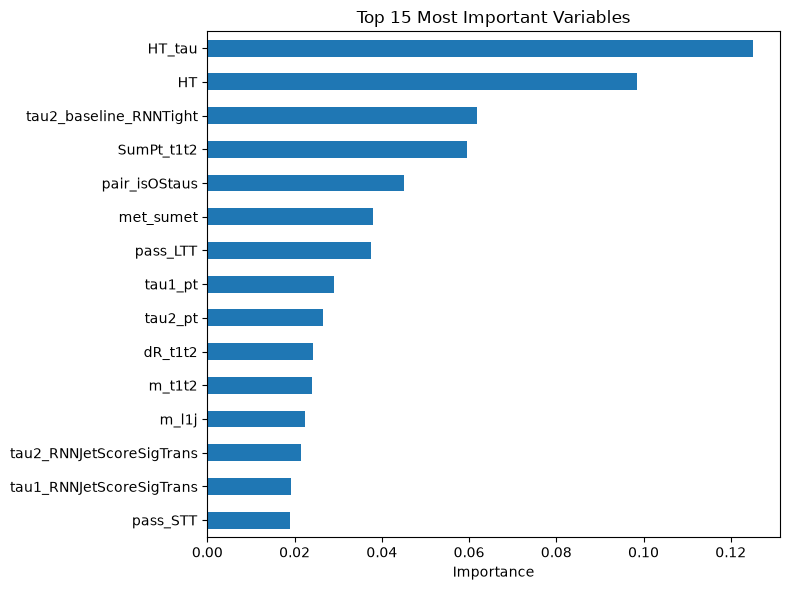

In [31]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

BLOCK_SUBSTR = ["weight", "w_phys", "effsf", "_ff", "truth", "istrue", "fake", "anti", "dsid", "eventnumber"]
BLOCK_EXACT  = {"n_b_jet", "pass1l2tau", "hhml_subchannelflavor"}

# separate label from features
y = data["label"]
X = data.drop(columns=["label"])

# find columns to block (substring match, case-insensitive + exact match)
block_cols = [
    c for c in X.columns
    if any(sub in c.lower() for sub in BLOCK_SUBSTR) or c.lower() in {b.lower() for b in BLOCK_EXACT}
]

# keep weight columns aside before dropping, so we can still use them as sample_weight
weight_cols = [c for c in X.columns if "weight" in c.lower()]
weight_df = X[weight_cols]

# drop all blocked columns from the feature set
X = X.drop(columns=block_cols)

# drop empty columns
nan_cols = X.columns[X.isna().all()]
X = X.drop(columns=nan_cols)

# split
X_train, X_val, y_train, y_val, train_weights, val_weights = train_test_split(
    X, y, weight_df, test_size=0.2, random_state=42
)

# normalise
scaler = MinMaxScaler()
X_train[X_train.columns] = scaler.fit_transform(X_train)
X_val[X_val.columns] = scaler.transform(X_val)

# class balance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# train
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="auc",
    early_stopping_rounds=30,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8
)

sample_weight = np.abs(train_weights["weight"] * train_weights["weights"])

model.fit(
    X_train, y_train,
    sample_weight=sample_weight,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# feature importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False)

print(top_features.head(15))

top_features.head(15).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Most Important Variables")
plt.tight_layout()
plt.savefig("feature_importance.png")